In [2]:
import pandas as pd
import numpy as np

In [3]:
path = r"C:\Users\chtou\Downloads\persuade_corpus_2.0_test\persuade_corpus_2.0_test.csv"
df = pd.read_csv(path, low_memory=False)

In [9]:
# Check how many Unannotated rows first
print("\nDiscourse type distribution (before):")
print(df['discourse_type'].value_counts(dropna=False))

# --------------------------------------------------
# Remove Unannotated rows
# --------------------------------------------------
df_clean = df[df['discourse_type'] != 'Unannotated'].copy()

# Reset index (important)
df_clean.reset_index(drop=True, inplace=True)
#-------------------------------------------------
# Check how many effectiveness rows first
#-------------------------------------------------
print("\nEfectiveness distribution (before):")
print(df['discourse_effectiveness'].value_counts(dropna=False))
# --------------------------------------------------
# Remove Adequete rows
# --------------------------------------------------
df_clean = df[df['discourse_effectiveness'] != 'Adequate'].copy()
df_clean = df_clean.dropna(subset=['discourse_effectiveness'])
# Reset index (important)
df_clean.reset_index(drop=True, inplace=True)
# --------------------------------------------------
# Check result
# --------------------------------------------------
print("\nAfter:", df_clean.shape)

print("\nDiscourse type distribution (after):")
print(df_clean['discourse_type'].value_counts(dropna=False))
print("\nEfectiveness distribution (after):")
print(df_clean['discourse_effectiveness'].value_counts(dropna=False))


Discourse type distribution (before):
discourse_type
Claim                   32376
Evidence                29886
Unannotated             18437
Position                10250
Concluding Statement     8778
Lead                     5793
Counterclaim             3717
Rebuttal                 2880
Name: count, dtype: int64

Efectiveness distribution (before):
discourse_effectiveness
Adequate       75363
NaN            18440
Effective      14089
Ineffective     4225
Name: count, dtype: int64

After: (18314, 27)

Discourse type distribution (after):
discourse_type
Evidence                6803
Claim                   5737
Concluding Statement    1882
Lead                    1387
Position                1369
Counterclaim             577
Rebuttal                 559
Name: count, dtype: int64

Efectiveness distribution (after):
discourse_effectiveness
Effective      14089
Ineffective     4225
Name: count, dtype: int64


In [10]:
output_path = r'C:\Users\chtou\Downloads\persuade_test_clean_no_unannotated.csv'
df_clean.to_csv(output_path, index=False)

print("Saved cleaned dataset to:", output_path)

Saved cleaned dataset to: C:\Users\chtou\Downloads\persuade_test_clean_no_unannotated.csv


Missing values before imputation:
ell_status                     716
grade_level                    694
student_disability_status     2560
economically_disadvantaged    2610
dtype: int64

===== Imputing: ell_status =====
Missing before: 716
Top important features:
['essay_word_count', 'race_ethnicity', 'grade_level', 'discourse_end', 'discourse_start', 'prompt_name', 'discourse_effectiveness', 'assignment', 'holistic_essay_score', 'economically_disadvantaged']
Missing after: 0

===== Imputing: grade_level =====
Missing before: 694
Top important features:
['assignment', 'prompt_name', 'task', 'provider', 'essay_word_count', 'student_disability_status', 'economically_disadvantaged', 'holistic_essay_score', 'discourse_end', 'discourse_start']
Missing after: 0

===== Imputing: student_disability_status =====
Missing before: 2560
Top important features:
['essay_word_count', 'discourse_end', 'discourse_start', 'holistic_essay_score', 'race_ethnicity', 'discourse_type_num', 'discourse_effecti

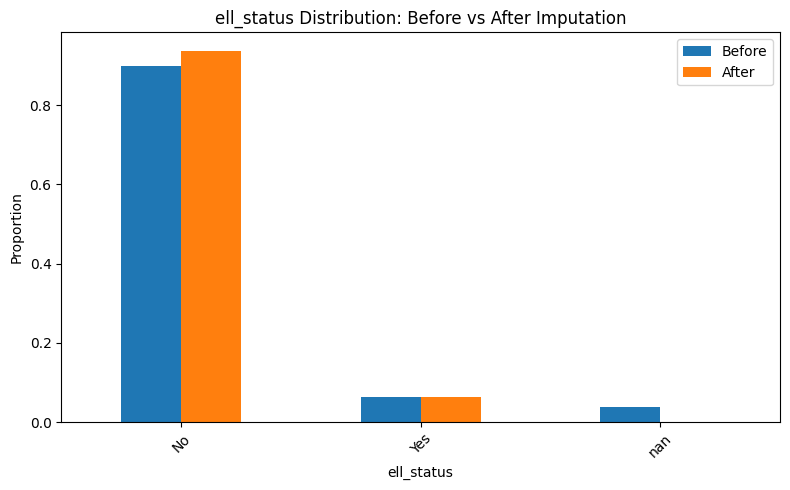

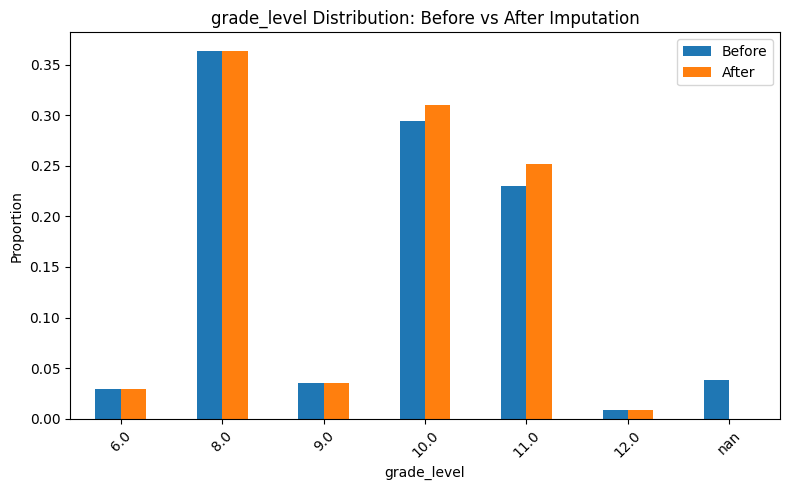

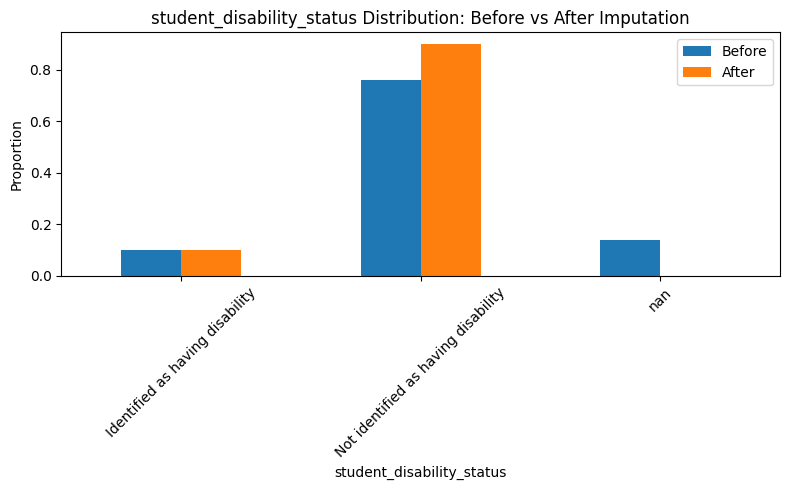

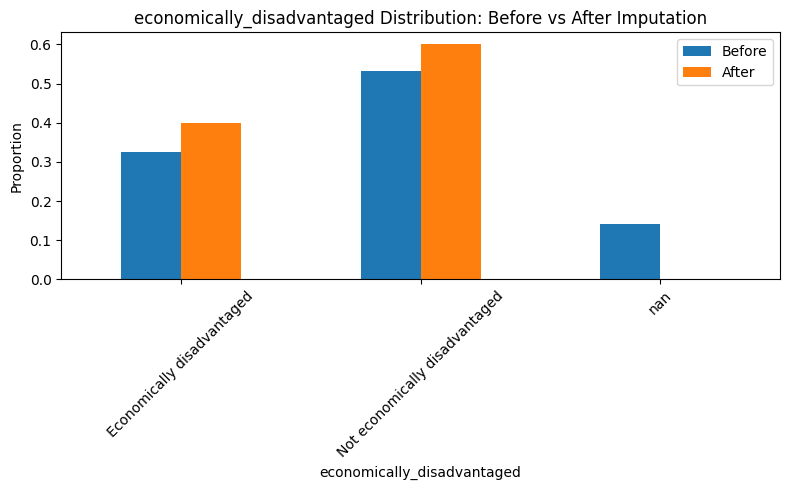

Saved imputed file to: C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1) Load data
# =========================
path = r'C:\Users\chtou\Downloads\persuade_test_clean_no_unannotated.csv'
df = pd.read_csv(path, low_memory=False)

# =========================
# 2) Convert hidden missing values to NaN
# =========================
# Handles empty strings and strings made only of spaces
df = df.replace(r'^\s*$', np.nan, regex=True)

# =========================
# 3) Drop unnecessary columns
# =========================
drop_cols = [
    'essay_id',
    'essay_id_comp',
    'competition_set',
    'discourse_id',
    'hierarchical_id',
    'hierarchical_text',
    'hierarchical_label'
]

# Free-text columns dropped for RF imputation
text_cols_to_drop = [
    'full_text',
    'discourse_text',
    'source_text'
]

df = df.drop(columns=drop_cols + text_cols_to_drop, errors='ignore')

# =========================
# 4) Columns to impute
# =========================
target_columns = [
    'ell_status',
    'grade_level',
    'student_disability_status',
    'economically_disadvantaged'
]

# Keep a copy before imputation for comparison
df_before = df.copy()

# =========================
# 5) Encode categorical columns
#    while preserving NaN
# =========================
df_encoded = df.copy()
encoding_maps = {}
decoding_maps = {}

cat_cols = df_encoded.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in cat_cols:
    df_encoded[col] = df_encoded[col].astype('object')
    
    non_null_values = pd.Series(df_encoded[col].dropna().unique())
    value_to_int = {val: idx for idx, val in enumerate(non_null_values)}
    int_to_value = {idx: val for val, idx in value_to_int.items()}
    
    encoding_maps[col] = value_to_int
    decoding_maps[col] = int_to_value
    
    df_encoded[col] = df_encoded[col].map(value_to_int)

# =========================
# 6) Function to impute one column
#    using important features
# =========================
def impute_with_rf(df_in, target_col, top_n=10, n_estimators=200, random_state=42):
    df_work = df_in.copy()

    print(f"\n===== Imputing: {target_col} =====")

    train_idx = df_work[target_col].notna()
    pred_idx = df_work[target_col].isna()

    print("Missing before:", pred_idx.sum())

    if pred_idx.sum() == 0:
        print(f"No missing values in {target_col}.")
        return df_work

    X_train = df_work.loc[train_idx].drop(columns=[target_col])
    y_train = df_work.loc[train_idx, target_col]

    X_pred = df_work.loc[pred_idx].drop(columns=[target_col])

    # Fill missing values in predictors only
    X_train = X_train.fillna(-1)
    X_pred = X_pred.fillna(-1)

    # Force categorical target to integer labels
    y_train = y_train.astype(int)

    # First model: get feature importance
    rf_full = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    rf_full.fit(X_train, y_train)

    importances = pd.Series(rf_full.feature_importances_, index=X_train.columns)
    important_features = importances.sort_values(ascending=False).head(top_n).index.tolist()

    print("Top important features:")
    print(important_features)

    # Second model: train only on top important features
    rf_top = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    rf_top.fit(X_train[important_features], y_train)

    # Predict missing values
    y_pred = rf_top.predict(X_pred[important_features])

    # Fill them back
    df_work.loc[pred_idx, target_col] = y_pred

    print("Missing after:", df_work[target_col].isna().sum())

    return df_work

# =========================
# 7) Check missing values before
# =========================
print("Missing values before imputation:")
print(df_encoded[target_columns].isna().sum())

# =========================
# 8) Impute each target column
# =========================
for col in target_columns:
    df_encoded = impute_with_rf(df_encoded, col, top_n=10)

# =========================
# 9) Check missing values after
# =========================
print("\nMissing values after imputation:")
print(df_encoded[target_columns].isna().sum())

# =========================
# 10) Decode categorical columns back
# =========================
df_imputed = df_encoded.copy()

for col in cat_cols:
    reverse_map = decoding_maps[col]
    df_imputed[col] = df_imputed[col].map(reverse_map)

# Optional: for grade_level if you want it numeric
# df_imputed['grade_level'] = pd.to_numeric(df_imputed['grade_level'], errors='coerce')

# =========================
# 11) Distribution tables
# =========================
for col in target_columns:
    print(f"\n===== {col} =====")
    
    before = df_before[col].value_counts(dropna=False, normalize=True)
    after = df_imputed[col].value_counts(dropna=False, normalize=True)
    
    comparison = pd.DataFrame({
        'Before': before,
        'After': after
    }).fillna(0)
    
    print(comparison)

# =========================
# 12) Distribution plots
# =========================
for col in target_columns:
    compare = pd.DataFrame({
        'Before': df_before[col].value_counts(normalize=True, dropna=False),
        'After': df_imputed[col].value_counts(normalize=True, dropna=False)
    }).fillna(0)

    compare.plot(kind='bar', figsize=(8, 5))
    plt.title(f"{col} Distribution: Before vs After Imputation")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# 13)  save
# =========================
output_path = r'C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed.csv'
df_imputed.to_csv(output_path, index=False)
print(f"Saved imputed file to: {output_path}")

In [13]:
# =========================================================
# 14) Reload the original cleaned dataset
#     to recover dropped columns
# =========================================================
path_original = r'C:\Users\chtou\Downloads\persuade_test_clean_no_unannotated.csv'
df_original = pd.read_csv(path_original, low_memory=False)

# Convert hidden missing values to NaN
df_original = df_original.replace(r'^\s*$', np.nan, regex=True)

# Reset index to make sure rows align
df_original = df_original.reset_index(drop=True)
df_imputed = df_imputed.reset_index(drop=True)

# =========================================================
# 15) Add back the columns you want
# =========================================================
cols_to_add = ['essay_id', 'discourse_text', 'full_text', 'source_text']

for col in cols_to_add:
    df_imputed[col] = df_original[col]

# =========================================================
# 16) Replace missing source_text with "without"
# =========================================================
df_imputed['source_text'] = df_imputed['source_text'].fillna('without')

# =========================================================
# 17) Check result
# =========================================================
print(df_imputed[['essay_id', 'discourse_text', 'full_text', 'source_text']].head())

print("\nMissing values in source_text after replacement:")
print(df_imputed['source_text'].isna().sum())

# =========================================================
# 18) Save final corrected dataset
# =========================================================
output_path = r'C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final.csv'
df_imputed.to_csv(output_path, index=False)

print(f"\nSaved final file to: {output_path}")

      essay_id                                     discourse_text  \
0  5.74361E+12  Another reason why we should not be able to us...   
1  5.74361E+12  The main key to not texting and driving while ...   
2  5.99979E+12  Driving is a good way to get whatever you need...   
3  5.99979E+12  Driving while holding your phone is illegal in...   
4  5.99979E+12  In conclusion driving with a phone present is ...   

                                           full_text source_text  
0  This essay will explain if drivers should or s...     without  
1  This essay will explain if drivers should or s...     without  
2  Phones and Driving\n\nDriving is a good way to...     without  
3  Phones and Driving\n\nDriving is a good way to...     without  
4  Phones and Driving\n\nDriving is a good way to...     without  

Missing values in source_text after replacement:
0

Saved final file to: C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final.csv


In [14]:
path = r"C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final.csv"
df = pd.read_csv(path, low_memory=False)

In [15]:
print("===== discourse_effectiveness Missing =====")
print(df['discourse_effectiveness'].isna().value_counts())

print("\nPercentage:")
print(df['discourse_effectiveness'].isna().mean() * 100, "%")

===== discourse_effectiveness Missing =====
discourse_effectiveness
False    18314
Name: count, dtype: int64

Percentage:
0.0 %


In [16]:
# =========================================================
#  Drop rows with missing discourse_effectiveness
# =========================================================
print("Before:", df.shape)

df = df[df['discourse_effectiveness'].notna()].copy()

print("After:", df.shape)

# Check
print("\nRemaining missing values:")
print(df['discourse_effectiveness'].isna().sum())

# =========================================================
# Save final dataset
# =========================================================
output_path = r'C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final_version.csv'
df.to_csv(output_path, index=False)

print(f"\nSaved final file to: {output_path}")

Before: (18314, 21)
After: (18314, 21)

Remaining missing values:
0

Saved final file to: C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final_version.csv


In [17]:
path = r"C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final_version.csv"
df = pd.read_csv(path, low_memory=False)

In [18]:
df.isnull().mean() * 100

holistic_essay_score          0.0
discourse_start               0.0
discourse_end                 0.0
discourse_type                0.0
discourse_type_num            0.0
discourse_effectiveness       0.0
provider                      0.0
task                          0.0
prompt_name                   0.0
assignment                    0.0
gender                        0.0
grade_level                   0.0
ell_status                    0.0
race_ethnicity                0.0
economically_disadvantaged    0.0
student_disability_status     0.0
essay_word_count              0.0
essay_id                      0.0
discourse_text                0.0
full_text                     0.0
source_text                   0.0
dtype: float64

In [19]:
import pandas as pd

path1 = r"C:\Users\chtou\Downloads\persuade_corpus_2.0_imputed_final_version.csv"
path2 = r"C:\Users\chtou\Downloads\persuade_test_corpus_2.0_imputed_final_version.csv"

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

In [20]:
print(df1.shape)
print(df2.shape)

(144289, 21)
(18314, 21)


In [21]:
persuade_main_corpus_version = pd.concat([df1, df2], ignore_index=True)

print(persuade_main_corpus_version.shape)

(162603, 21)


In [22]:
dup_percent = persuade_main_corpus_version.duplicated().mean() * 100
print(f"Duplicate rows: {dup_percent:.2f}%")

Duplicate rows: 0.00%


In [23]:
dup_percent_text = persuade_main_corpus_version.duplicated(subset=['full_text']).mean() * 100
print(f"Duplicate texts: {dup_percent_text:.2f}%")
num_dup = persuade_main_corpus_version.duplicated(subset=['full_text']).sum()
print("Number of duplicate texts:", num_dup)
persuade_main_corpus_version['full_text_clean'] = (
    persuade_main_corpus_version['full_text']
    .str.strip()
    .str.lower()
)

dup_percent_clean = (
    persuade_main_corpus_version
    .duplicated(subset=['full_text_clean'])
    .mean() * 100
)

print(f"Duplicate texts (cleaned): {dup_percent_clean:.2f}%")

Duplicate texts: 86.64%
Number of duplicate texts: 140879
Duplicate texts (cleaned): 86.64%


In [24]:
output_path = r"C:\Users\chtou\Downloads\persuade_main_corpus_version.csv"

persuade_main_corpus_version.to_csv(output_path, index=False)

In [25]:
path= r"C:\Users\chtou\Downloads\persuade_main_corpus_version.csv"
df = pd.read_csv(path, low_memory=False)
print("\nEfectiveness distribution (before):")
print(df['discourse_effectiveness'].value_counts(dropna=False))


Efectiveness distribution (before):
discourse_effectiveness
Adequate       113244
Effective       38672
Ineffective     10687
Name: count, dtype: int64


In [3]:
path= r"C:\Users\chtou\Downloads\persuade_main_corpus_version.csv"
df = pd.read_csv(path, low_memory=False)

In [4]:
# Print all columns (variables) in your dataset
print("Dataset Variables / Columns:\n")
for col in df.columns:
    print(col)

# Show data types and non-null counts
print("\n\nDataset Attributes (info):\n")
df.info()

# Detailed summary for all columns
print("\n\nDetailed Description:\n")
print(df.describe(include='all').transpose())

# Optional: Print unique values count for each variable
print("\n\nUnique Values Per Variable:\n")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Dataset Variables / Columns:

holistic_essay_score
discourse_start
discourse_end
discourse_type
discourse_type_num
discourse_effectiveness
provider
task
prompt_name
assignment
gender
grade_level
ell_status
race_ethnicity
economically_disadvantaged
student_disability_status
essay_word_count
essay_id
discourse_text
full_text
source_text
full_text_clean


Dataset Attributes (info):

<class 'pandas.DataFrame'>
RangeIndex: 162603 entries, 0 to 162602
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   holistic_essay_score        162603 non-null  int64  
 1   discourse_start             162603 non-null  int64  
 2   discourse_end               162603 non-null  int64  
 3   discourse_type              162603 non-null  str    
 4   discourse_type_num          162603 non-null  str    
 5   discourse_effectiveness     162603 non-null  str    
 6   provider                    162603 non-null  str

In [5]:
# Print each variable with all its unique values

for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Variable: {col}")
    print(f"Number of Unique Values: {df[col].nunique()}")
    print("Unique Values:")
    print(df[col].dropna().unique())


Variable: holistic_essay_score
Number of Unique Values: 6
Unique Values:
[3 4 5 2 6 1]

Variable: discourse_start
Number of Unique Values: 5103
Unique Values:
[   8  230  313 ... 4738 4728 4122]

Variable: discourse_end
Number of Unique Values: 5570
Unique Values:
[ 229  312  400 ... 5215 5231 5925]

Variable: discourse_type
Number of Unique Values: 7
Unique Values:
<ArrowStringArray>
[                'Lead',             'Position',             'Evidence',
                'Claim', 'Concluding Statement',         'Counterclaim',
             'Rebuttal']
Length: 7, dtype: str

Variable: discourse_type_num
Number of Unique Values: 44
Unique Values:
<ArrowStringArray>
[                'Lead 1',             'Position 1',             'Evidence 1',
             'Evidence 2',                'Claim 1',             'Evidence 3',
             'Evidence 4',                'Claim 2',             'Evidence 5',
 'Concluding Statement 1',         'Counterclaim 1',             'Rebuttal 1',
          

In [7]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
selected_columns = [
    'holistic_essay_score',
    'discourse_start',
    'discourse_end',
    'discourse_type',
    'discourse_type_num',
    'discourse_effectiveness',
    'provider',
    'task',
    'prompt_name',
    'assignment',
    'gender',
    'grade_level',
    'ell_status',
    'race_ethnicity',
    'economically_disadvantaged',
    'student_disability_status',
    'essay_word_count',
    'essay_id',
    'discourse_text',
    'full_text',
    'source_text'
]

for col in selected_columns:
    print("\n" + "="*80)
    print(f"VARIABLE: {col}")
    print("="*80)

    print("\nMissing values:")
    print(df[col].isna().sum())

    print("\nNumber of unique values:")
    print(df[col].nunique(dropna=False))

    print("\nDistribution / value counts:")
    print(df[col].value_counts(dropna=False).head(30))

    if df[col].dtype == "object":
        print("\nText length distribution:")
        lengths = df[col].dropna().astype(str).str.len()
        print(lengths.describe())
    else:
        print("\nNumeric distribution:")
        print(df[col].describe())


VARIABLE: holistic_essay_score

Missing values:
0

Number of unique values:
6

Distribution / value counts:
holistic_essay_score
4    47951
3    47577
5    29510
2    24512
6     9826
1     3227
Name: count, dtype: int64

Numeric distribution:
count    162603.000000
mean          3.648715
std           1.172181
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           6.000000
Name: holistic_essay_score, dtype: float64

VARIABLE: discourse_start

Missing values:
0

Number of unique values:
5103

Distribution / value counts:
discourse_start
0      13166
17      1218
20       541
21       310
15       263
18       215
19       212
16       141
476      136
298      136
247      135
254      133
280      132
370      131
264      130
193      130
131      130
374      130
376      129
281      129
345      129
356      128
302      128
394      128
324      127
288      127
361      127
391      127
400      126
331      126
Name: count, dt